# Tugas Praktikum 2: Praproses Data
## Dataset: House Prices - Advanced Regression Techniques (`train.csv`)

Notebook ini berisi tahapan praproses data sesuai panduan praktikum:
1. Import dan pemeriksaan awal dataset
2. Pembersihan data (missing value)
3. Deteksi dan penanganan outlier
4. Transformasi data (standarisasi dan one-hot encoding)
5. Reduksi dimensi (analisis korelasi dan PCA)
6. Ringkasan dan ekspor dataset hasil preprocessing

## 1. Import Library dan Dataset

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)

df = pd.read_csv('dataset-train/train.csv')
original_rows = len(df)

print("Dataset berhasil dimuat.")
print("Shape dataset awal:", df.shape)

Dataset berhasil dimuat.
Shape dataset awal: (1460, 81)


In [67]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [68]:
print("Shape dataset:", df.shape)

Shape dataset: (1460, 81)


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

**Penjelasan:** Dataset awal berisi 1460 baris dan 81 kolom. `Id` merupakan identifier, sedangkan `SalePrice` merupakan target harga rumah. `Id` akan dipertahankan untuk traceability, tetapi tidak digunakan sebagai fitur dalam preprocessing statistik.

## 2. Pembersihan Data
### 2.1 Pemeriksaan Nilai yang Hilang

In [70]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Jumlah Hilang': missing,
    'Persentase (%)': missing_pct
})

display(missing_summary)

,Jumlah Hilang,Persentase (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


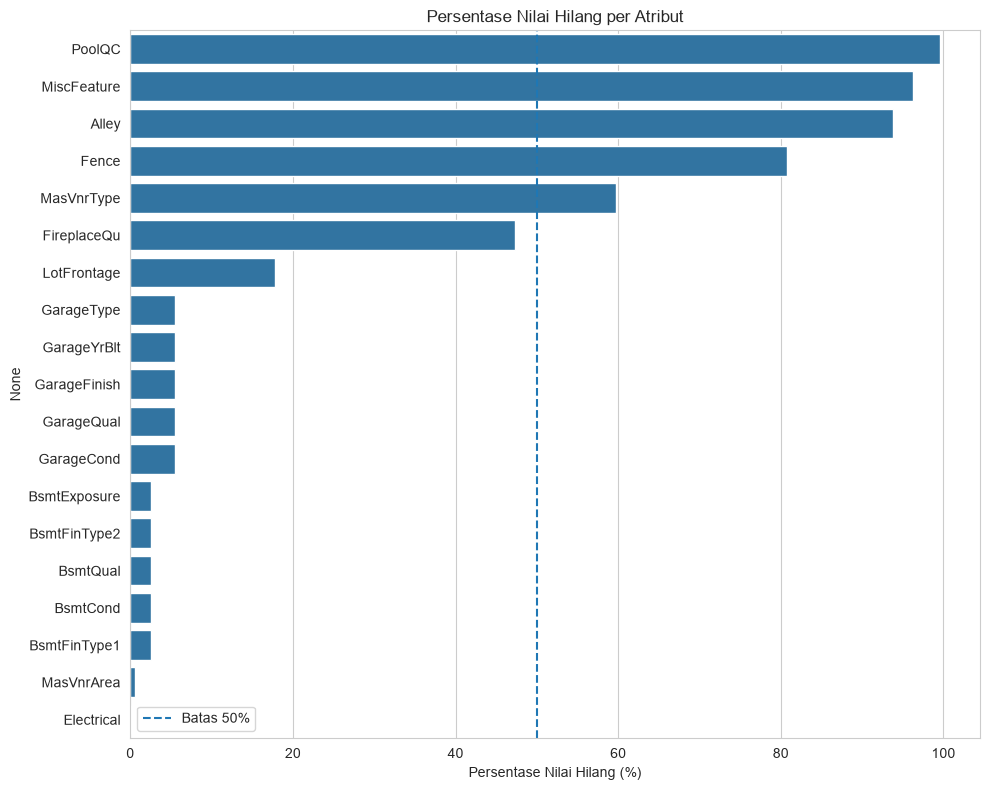

In [71]:
plt.figure(figsize=(10, 8))
sns.barplot(
    x=missing_pct.values,
    y=missing_pct.index
)
plt.xlabel('Persentase Nilai Hilang (%)')
plt.title('Persentase Nilai Hilang per Atribut')
plt.axvline(
    50,
    linestyle='--',
    label='Batas 50%'
)
plt.legend()
plt.tight_layout()
plt.show()

**Hasil:** Berdasarkan pemeriksaan persentase nilai hilang, terdapat 5 atribut dengan proporsi nilai hilang lebih dari 50%, yaitu `PoolQC`, `MiscFeature`, `Alley`, `Fence`, dan `MasVnrType`. Kelima atribut tersebut dihapus karena memiliki proporsi nilai hilang yang tinggi.

In [72]:
# Hapus kolom dengan proporsi nilai hilang > 50%
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()

print("Kolom yang dihapus (>50% missing):")
print(cols_to_drop)

df = df.drop(columns=cols_to_drop)

print("Shape setelah menghapus kolom dengan missing value tinggi:", df.shape)

Kolom yang dihapus (>50% missing):
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']
Shape setelah menghapus kolom dengan missing value tinggi: (1460, 76)


### 2.2 Penanganan Nilai Hilang

Untuk atribut kategorikal yang merepresentasikan fasilitas rumah, nilai `NaN` diisi dengan `"None"` karena menunjukkan ketiadaan fasilitas. Untuk atribut numerik, nilai hilang diisi menggunakan median. Atribut kategorikal lain dengan proporsi missing yang kecil diisi menggunakan modus.

In [73]:
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("Kolom yang masih memiliki missing value:")
display(remaining_missing)

Kolom yang masih memiliki missing value:


FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageFinish     81
GarageType       81
GarageQual       81
GarageCond       81
BsmtExposure     38
BsmtFinType2     38
BsmtCond         37
BsmtQual         37
BsmtFinType1     37
MasVnrArea        8
Electrical        1
dtype: int64

In [74]:
# Pisahkan kolom numerik dan kategorikal yang masih memiliki missing value.
num_missing_cols = (
    df[remaining_missing.index]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

cat_missing_cols = (
    df[remaining_missing.index]
    .select_dtypes(include=['object'])
    .columns
    .tolist()
)

print("Kolom numerik dengan missing value:", num_missing_cols)
print("Kolom kategorikal dengan missing value:", cat_missing_cols)

Kolom numerik dengan missing value: ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']
Kolom kategorikal dengan missing value: ['FireplaceQu', 'GarageFinish', 'GarageType', 'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType2', 'BsmtCond', 'BsmtQual', 'BsmtFinType1', 'Electrical']


C:\Users\Lio\AppData\Local\Temp\ipykernel_10828\706926730.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(include=['object'])


In [75]:
# Isi nilai hilang numerik dengan median.
for col in num_missing_cols:
    df[col] = df[col].fillna(df[col].median())

# Kolom fasilitas rumah yang kosong diisi "None".
# MasVnrType tidak termasuk karena sudah dihapus pada tahap >50% missing.
none_fill_cols = [
    c for c in cat_missing_cols
    if c.startswith(('Garage', 'Bsmt', 'Fireplace'))
]

other_cat_cols = [c for c in cat_missing_cols if c not in none_fill_cols]

for col in none_fill_cols:
    df[col] = df[col].fillna('None')

# Atribut kategorikal lain dengan missing yang sangat kecil diisi modus.
for col in other_cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Total nilai hilang tersisa:", int(df.isnull().sum().sum()))

Total nilai hilang tersisa: 0


**Hasil:** Setelah tahap pembersihan, seluruh nilai hilang yang tersisa telah ditangani. Strategi imputasi disesuaikan dengan tipe dan konteks atribut.

## 3. Deteksi dan Penanganan Outlier

Deteksi outlier dilakukan menggunakan boxplot dan ringkasan IQR pada atribut numerik.

`Id` tidak diperiksa karena hanya identifier. `MSSubClass` juga tidak diperlakukan sebagai variabel numerik kontinu karena nilainya merupakan kode kelas bangunan, kolom ini akan diproses sebagai atribut kategorikal pada tahap encoding. `SalePrice` tetap diperiksa melalui boxplot, tetapi tidak dimodifikasi karena merupakan target.

In [76]:
# MSSubClass masih berupa integer pada dataset, tetapi secara semantik diperlakukan sebagai kategorikal.
# Id juga tidak digunakan dalam pemeriksaan outlier.
outlier_numeric_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in ['Id', 'MSSubClass']
]

print("Jumlah atribut numerik yang diperiksa:", len(outlier_numeric_cols))
print(outlier_numeric_cols)

Jumlah atribut numerik yang diperiksa: 36
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [77]:
def iqr_outlier_summary(data, columns):
    rows = []

    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_mask = (data[col] < lower) | (data[col] > upper)
        count = int(outlier_mask.sum())

        rows.append({
            'Atribut': col,
            'Batas Bawah': lower,
            'Batas Atas': upper,
            'Jumlah Outlier': count,
            'Persentase Outlier (%)': round(count / len(data) * 100, 2)
        })

    return (
        pd.DataFrame(rows)
        .sort_values('Persentase Outlier (%)', ascending=False)
        .reset_index(drop=True)
    )

outlier_summary = iqr_outlier_summary(df, outlier_numeric_cols)
display(outlier_summary)

,Atribut,Batas Bawah,Batas Atas,Jumlah Outlier,Persentase Outlier (%)
0,EnclosedPorch,0.000,0.000,208,14.25
1,BsmtFinSF2,0.000,0.000,167,11.44
2,OverallCond,3.500,7.500,125,8.56
3,ScreenPorch,0.000,0.000,116,7.95
4,LotFrontage,31.500,107.500,106,7.26
5,MasVnrArea,-246.375,410.625,98,6.71
6,BsmtHalfBath,0.000,0.000,82,5.62
7,OpenPorchSF,-102.000,170.000,77,5.27
8,LotArea,1481.500,17673.500,69,4.73
9,KitchenAbvGr,1.000,1.000,68,4.66


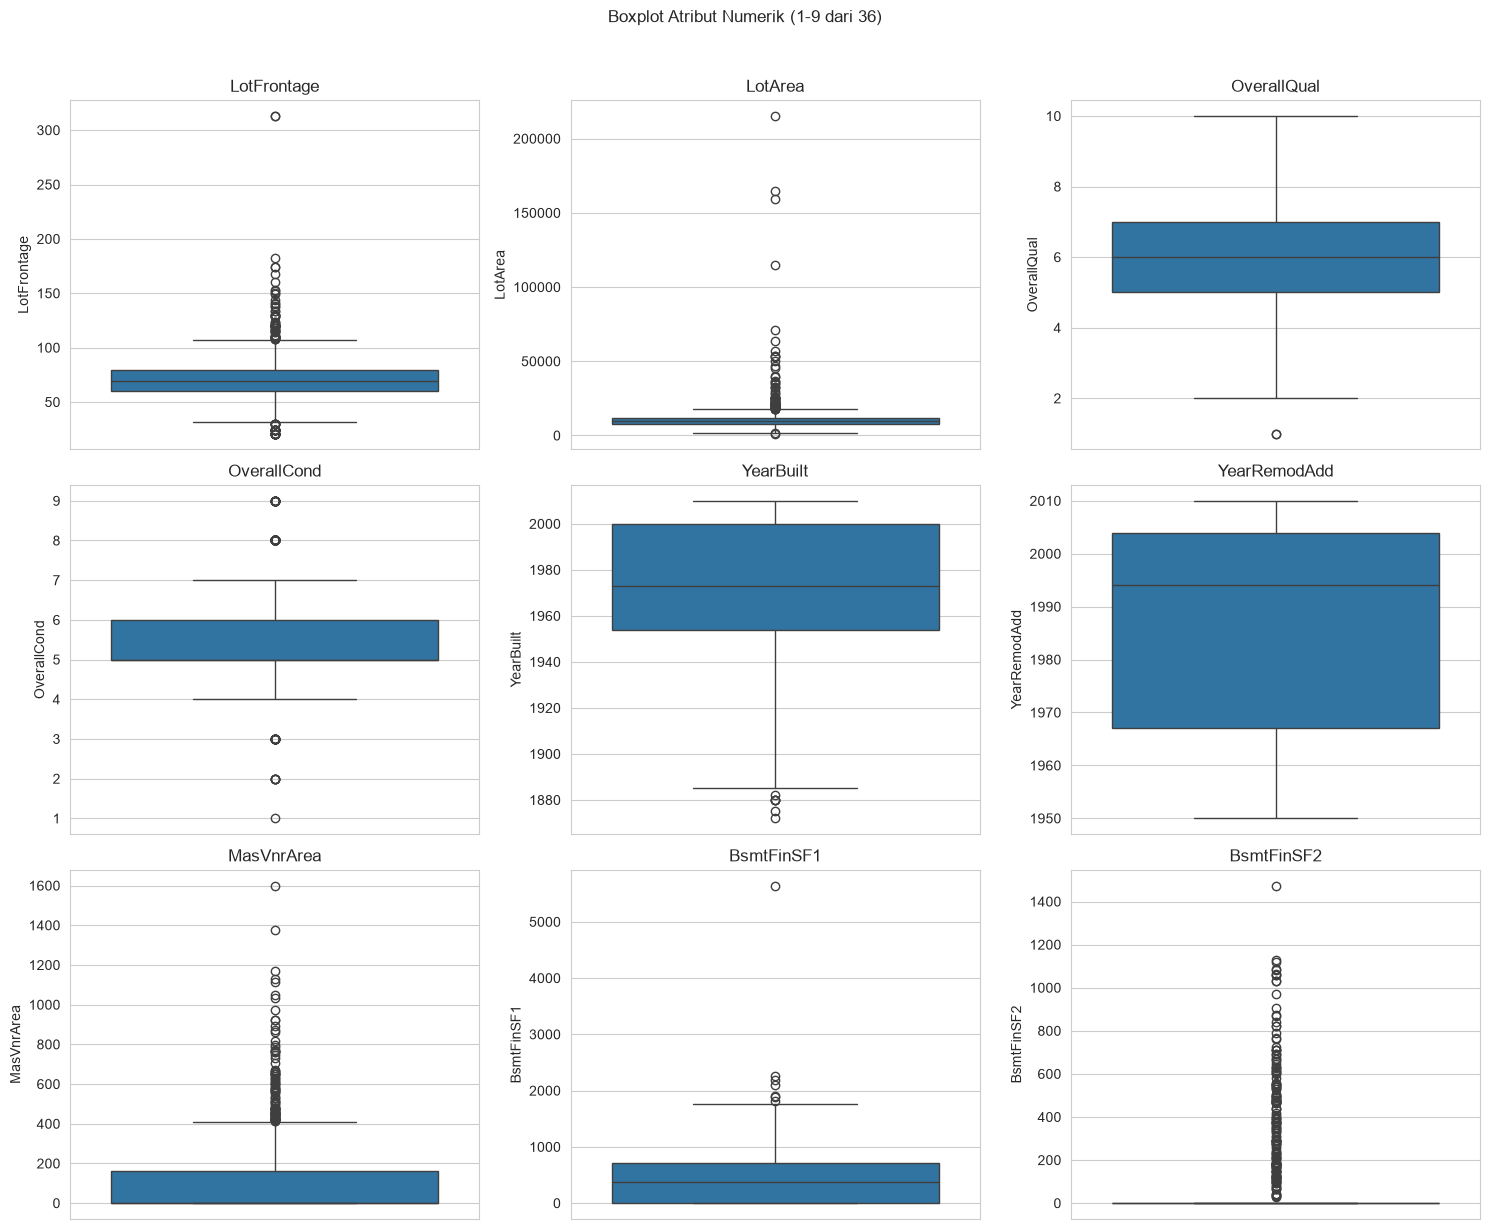

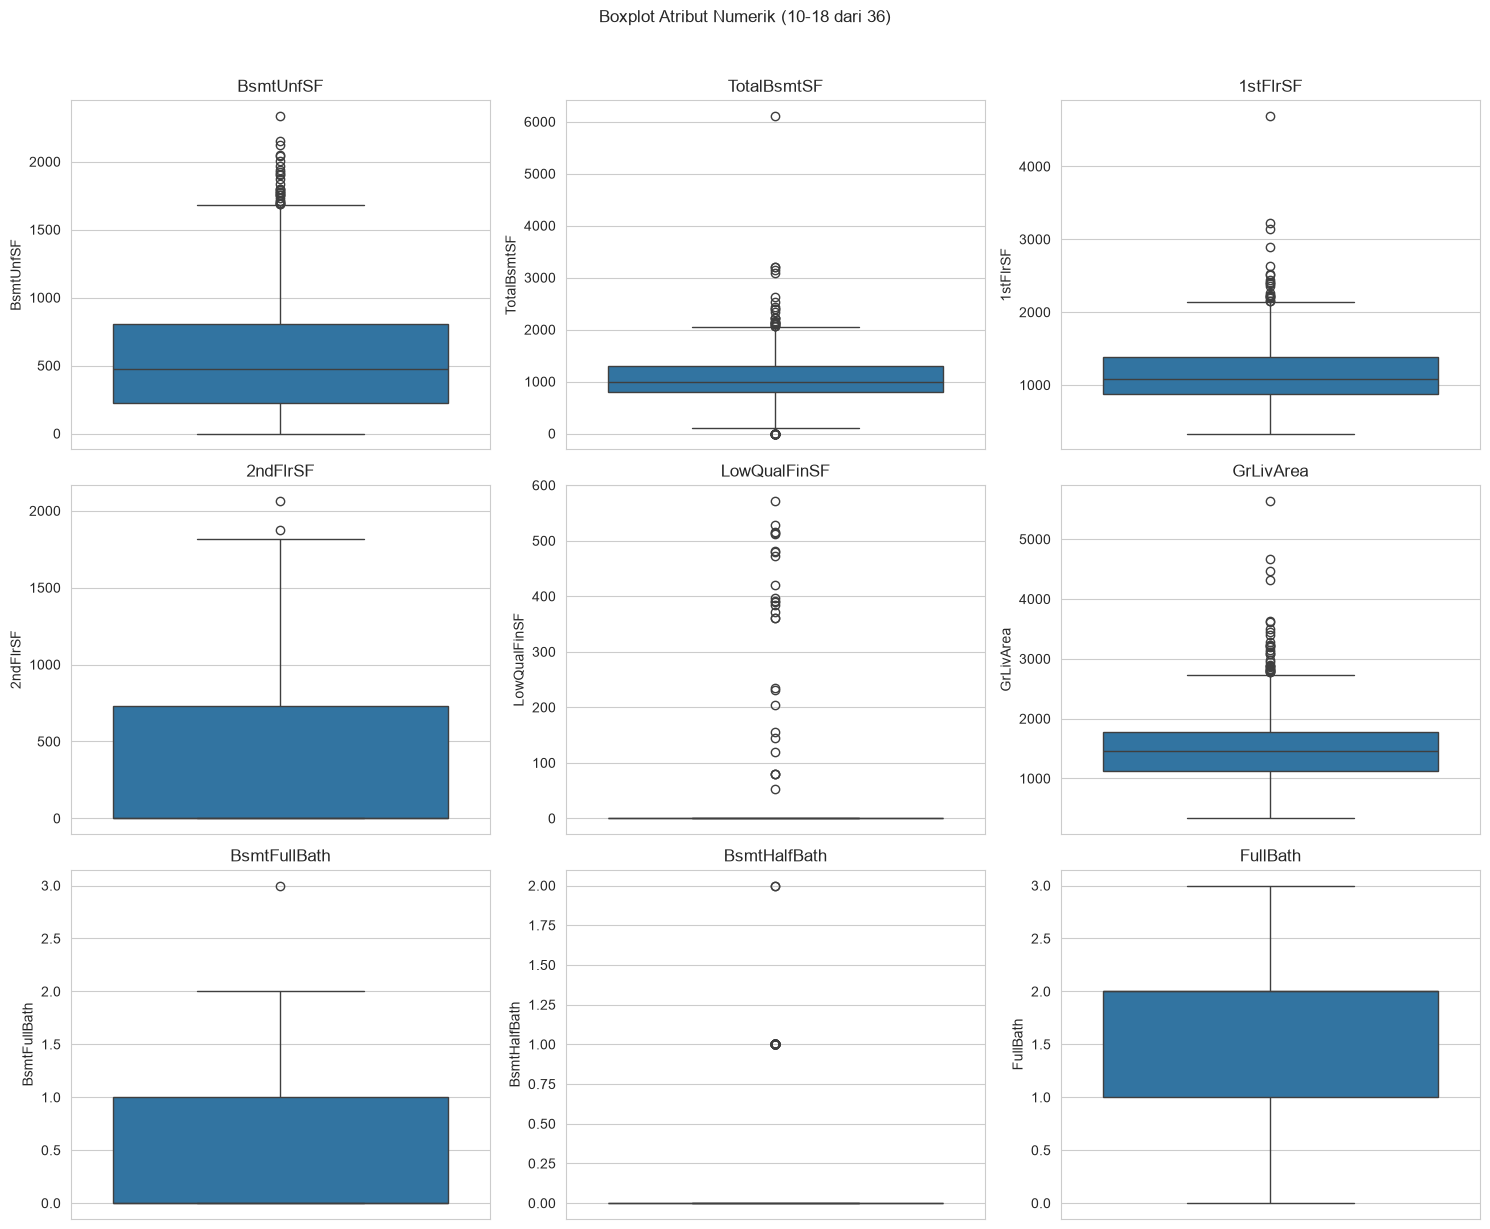

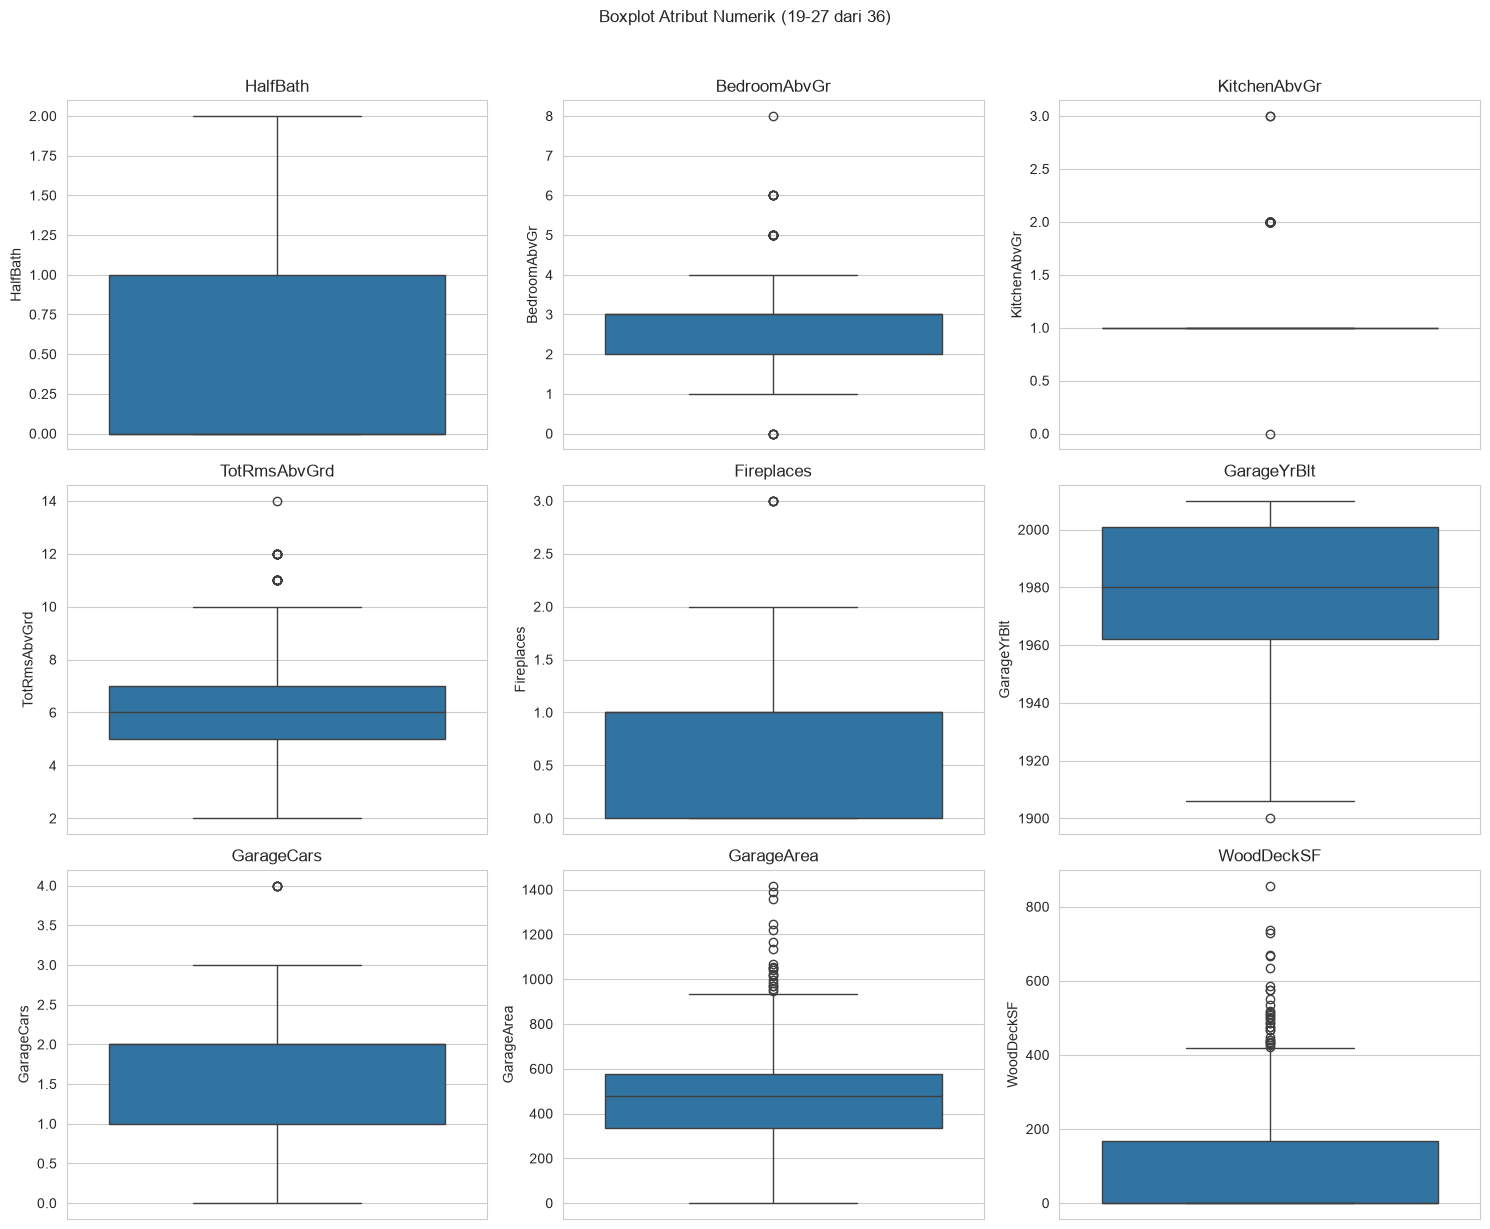

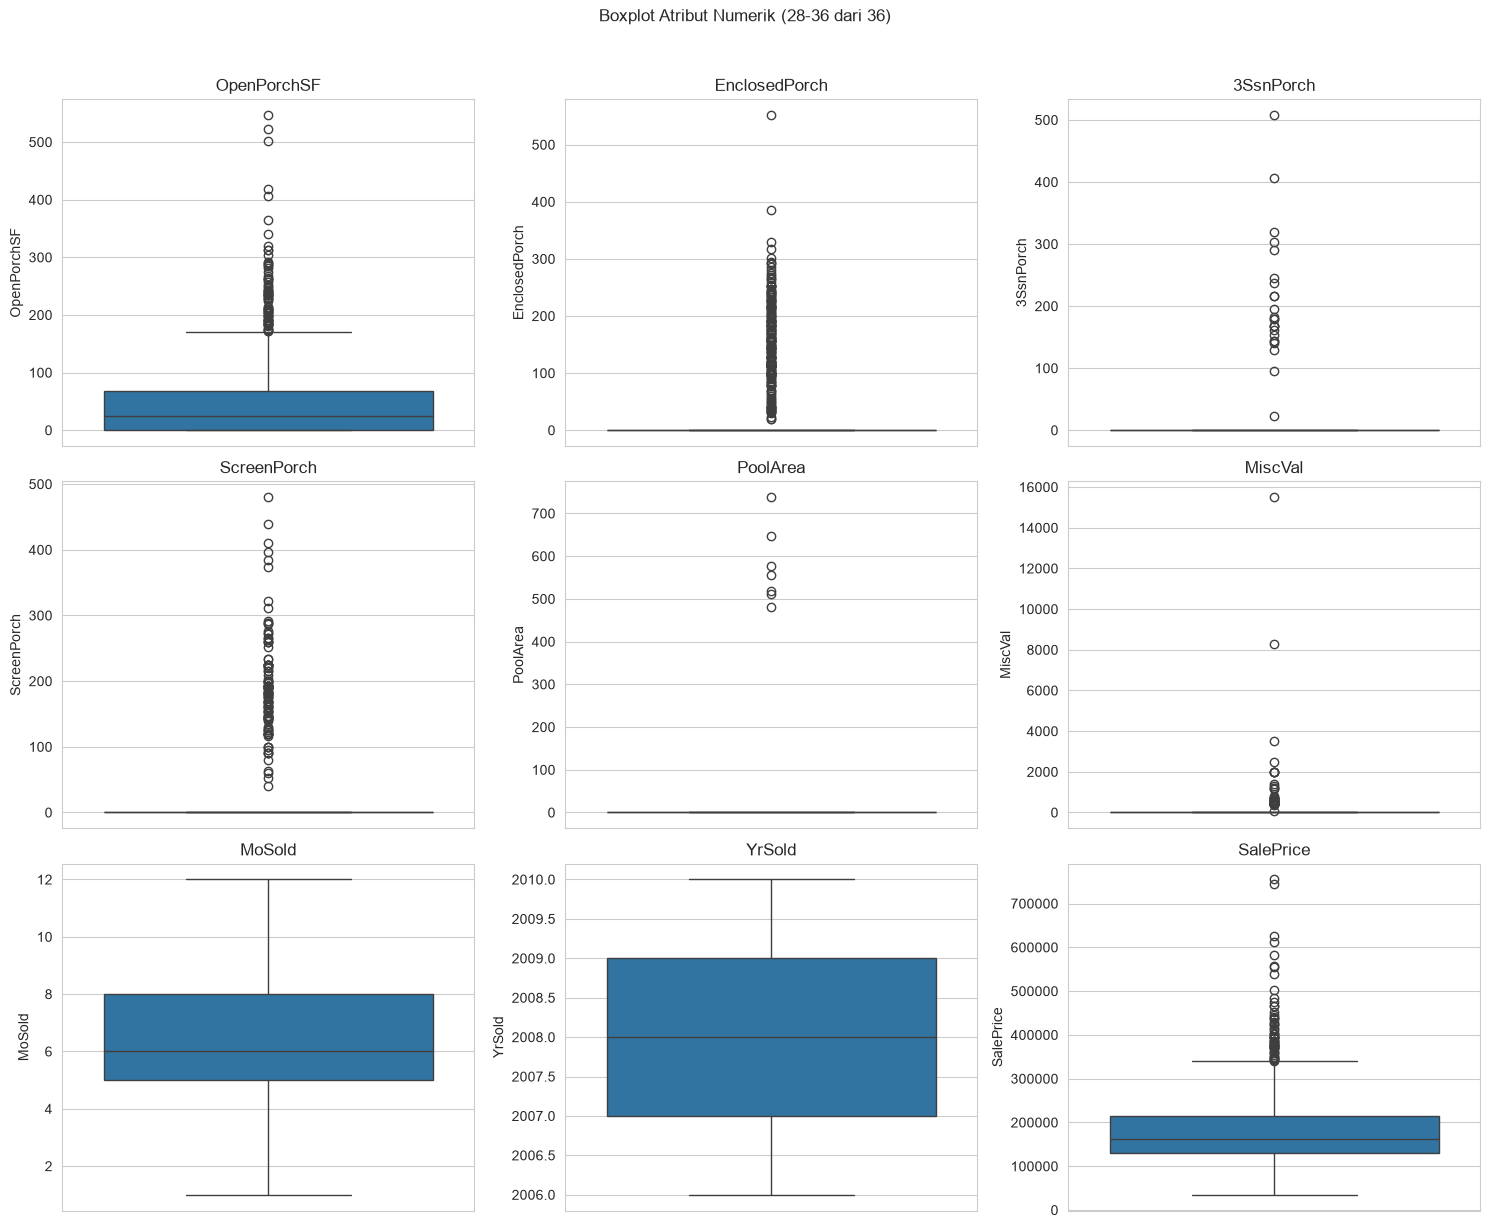

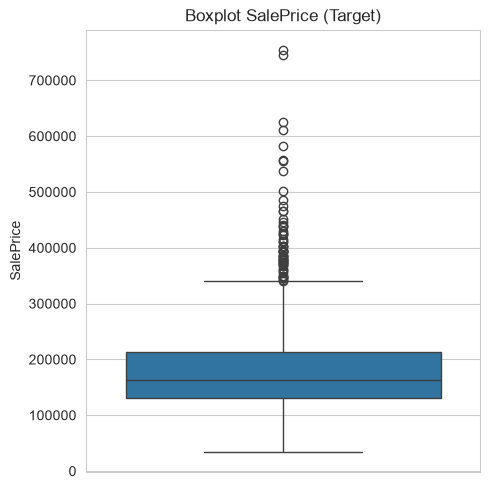

In [78]:
# Boxplot seluruh atribut numerik yang diperiksa, dibagi menjadi beberapa gambar agar tetap terbaca.
plot_cols = outlier_numeric_cols

for start in range(0, len(plot_cols), 9):
    cols = plot_cols[start:start + 9]

    ncols = 3
    nrows = int(np.ceil(len(cols) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15, 4 * nrows)
    )

    axes = np.atleast_1d(axes).reshape(-1)

    for ax, col in zip(axes, cols):
        sns.boxplot(y=df[col], ax=ax)
        ax.set_title(col)

    for ax in axes[len(cols):]:
        ax.axis('off')

    fig.suptitle(
        f'Boxplot Atribut Numerik ({start + 1}-{start + len(cols)} dari {len(plot_cols)})',
        y=1.02
    )
    plt.tight_layout()
    plt.show()

# SalePrice ditampilkan secara terpisah karena merupakan target.
plt.figure(figsize=(5, 5))
sns.boxplot(y=df['SalePrice'])
plt.title('Boxplot SalePrice (Target)')
plt.tight_layout()
plt.show()

### 3.1 Penanganan Outlier Terpilih

Berdasarkan pemeriksaan boxplot dan ringkasan IQR, penanganan difokuskan pada atribut ukuran rumah yang menunjukkan nilai ekstrem dan tetap merupakan fitur numerik kontinu, yaitu `LotArea`, `GrLivArea`, `TotalBsmtSF`, dan `1stFlrSF`.

Outlier pada atribut tersebut disesuaikan menggunakan **IQR capping**, bukan dihapus. Cara ini mempertahankan seluruh observasi sambil membatasi pengaruh nilai yang sangat ekstrem.

`SalePrice` tidak di-capping dan tidak dihapus. Kolom tersebut tetap diperiksa secara visual, tetapi dipertahankan apa adanya karena merupakan target.

In [79]:
def iqr_capping(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return series.clip(lower=lower, upper=upper)

cols_to_cap = [
    'LotArea',
    'GrLivArea',
    'TotalBsmtSF',
    '1stFlrSF'
]

display(
    outlier_summary[
        outlier_summary['Atribut'].isin(cols_to_cap)
    ].set_index('Atribut')
)

for col in cols_to_cap:
    df[col] = iqr_capping(df[col])

print("Outlier yang dipilih telah di-capping menggunakan metode IQR.")

,Batas Bawah,Batas Atas,Jumlah Outlier,Persentase Outlier (%)
Atribut,,,,
LotArea,1481.500,17673.500,69,4.73
TotalBsmtSF,42.000,2052.000,61,4.18
GrLivArea,158.625,2747.625,31,2.12
1stFlrSF,118.125,2155.125,20,1.37


Outlier yang dipilih telah di-capping menggunakan metode IQR.


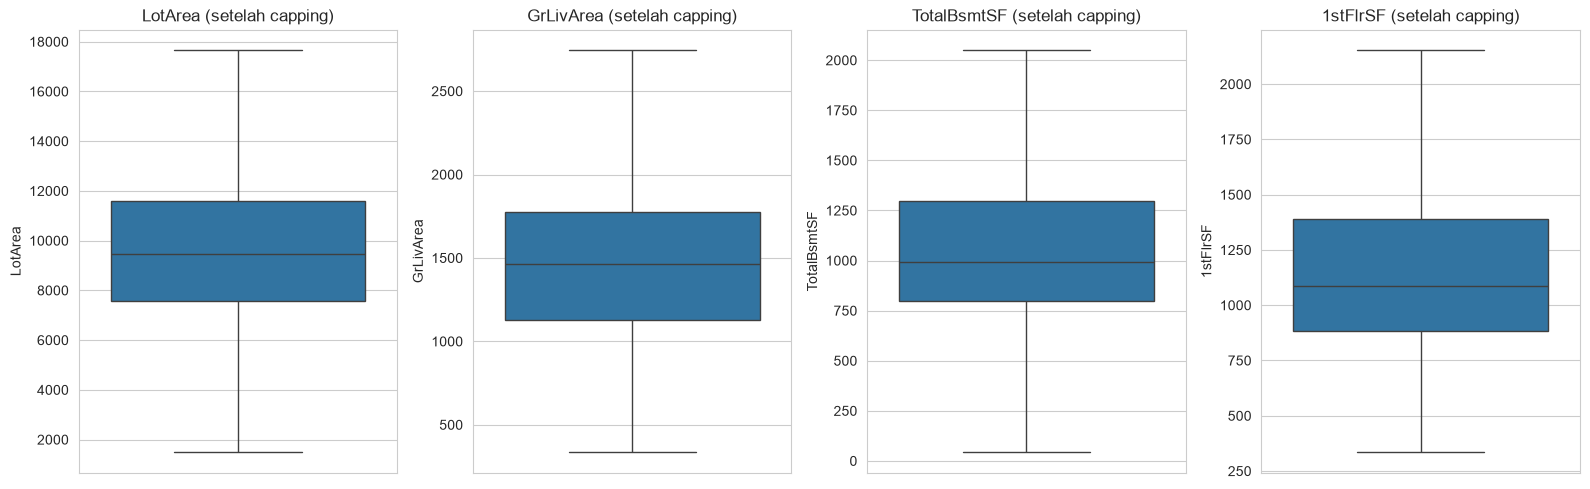

In [80]:
fig, axes = plt.subplots(
    1,
    len(cols_to_cap),
    figsize=(16, 5)
)

for ax, col in zip(axes, cols_to_cap):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'{col} (setelah capping)')

plt.tight_layout()
plt.show()

**Hasil:** Nilai ekstrem pada atribut yang dipilih dibatasi pada batas IQR tanpa menghapus baris data. `SalePrice` tetap mempertahankan nilai aslinya.

## 4. Transformasi Data
### 4.1 Normalisasi/Standarisasi

`MSSubClass` diperlakukan sebagai atribut kategorikal sehingga tidak ikut StandardScaler. `Id` juga tidak ikut scaling karena hanya identifier. Atribut numerik lainnya, kecuali `SalePrice`, distandarisasi menggunakan **StandardScaler (z-score)**.

In [81]:
# MSSubClass diperlakukan sebagai kategori, bukan sebagai numerik kontinu.
df['MSSubClass'] = df['MSSubClass'].astype(str)

numeric_feature_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in ['Id', 'SalePrice']
]

scaler = StandardScaler()
df[numeric_feature_cols] = scaler.fit_transform(
    df[numeric_feature_cols]
)

print("Jumlah fitur numerik yang distandarisasi:", len(numeric_feature_cols))
print("Id tidak distandarisasi.")
print("SalePrice tidak distandarisasi.")
print("MSSubClass diproses sebagai kategorikal.")

display(
    df[numeric_feature_cols]
    .describe()
    .T[['mean', 'std']]
    .head(10)
)

Jumlah fitur numerik yang distandarisasi: 35
Id tidak distandarisasi.
SalePrice tidak distandarisasi.
MSSubClass diproses sebagai kategorikal.


,mean,std
LotFrontage,2.798370e-16,1.000343
LotArea,5.535907e-17,1.000343
OverallQual,1.387018e-16,1.000343
OverallCond,3.540547e-16,1.000343
YearBuilt,1.046347e-15,1.000343
YearRemodAdd,4.496860e-15,1.000343
MasVnrArea,-3.893385e-17,1.000343
BsmtFinSF1,-2.433366e-17,1.000343
BsmtFinSF2,-3.406712e-17,1.000343
BsmtUnfSF,-6.600504e-17,1.000343


**Hasil:** Fitur numerik yang dipilih memiliki mean mendekati 0 dan standar deviasi mendekati 1 setelah standardisasi. `Id` dan `SalePrice` sengaja tidak diubah, sedangkan `MSSubClass` akan diubah melalui one-hot encoding.

### 4.2 One-Hot Encoding Atribut Kategoris

In [82]:
categorical_cols = (
    df.select_dtypes(include=['object', 'category'])
    .columns
    .tolist()
)

print("Jumlah atribut kategorikal:", len(categorical_cols))
print(categorical_cols)

Jumlah atribut kategorikal: 39
['MSSubClass', 'MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


C:\Users\Lio\AppData\Local\Temp\ipykernel_10828\3522119376.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object', 'category'])


In [83]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("Shape sebelum encoding:", df.shape)
print("Shape setelah one-hot encoding:", df_encoded.shape)

# Pastikan hasil encoding berupa 0/1 numerik, bukan boolean.
dummy_cols = [
    c for c in df_encoded.columns
    if c not in df.columns
]

if dummy_cols:
    assert set(
        df_encoded[dummy_cols].stack().unique()
    ).issubset({0, 1}), "Ditemukan nilai selain 0/1 pada kolom dummy."

print("Kolom hasil one-hot encoding menggunakan representasi 0/1.")

Shape sebelum encoding: (1460, 76)
Shape setelah one-hot encoding: (1460, 258)
Kolom hasil one-hot encoding menggunakan representasi 0/1.


**Hasil:** Atribut kategorikal diubah menjadi kolom biner 0/1 menggunakan one-hot encoding dengan `drop_first=True`. `MSSubClass` juga masuk ke tahap ini karena telah diperlakukan sebagai kategorikal.

## 5. Reduksi Dimensi
### 5.1 Analisis Korelasi

Analisis korelasi digunakan untuk menemukan pasangan **fitur** yang sangat berkorelasi. `Id` dan `SalePrice` tidak digunakan dalam proses pemilihan atribut yang dibuang. Dengan demikian, correlation-based reduction dilakukan antar-feature dan tidak dapat menghapus target `SalePrice`.

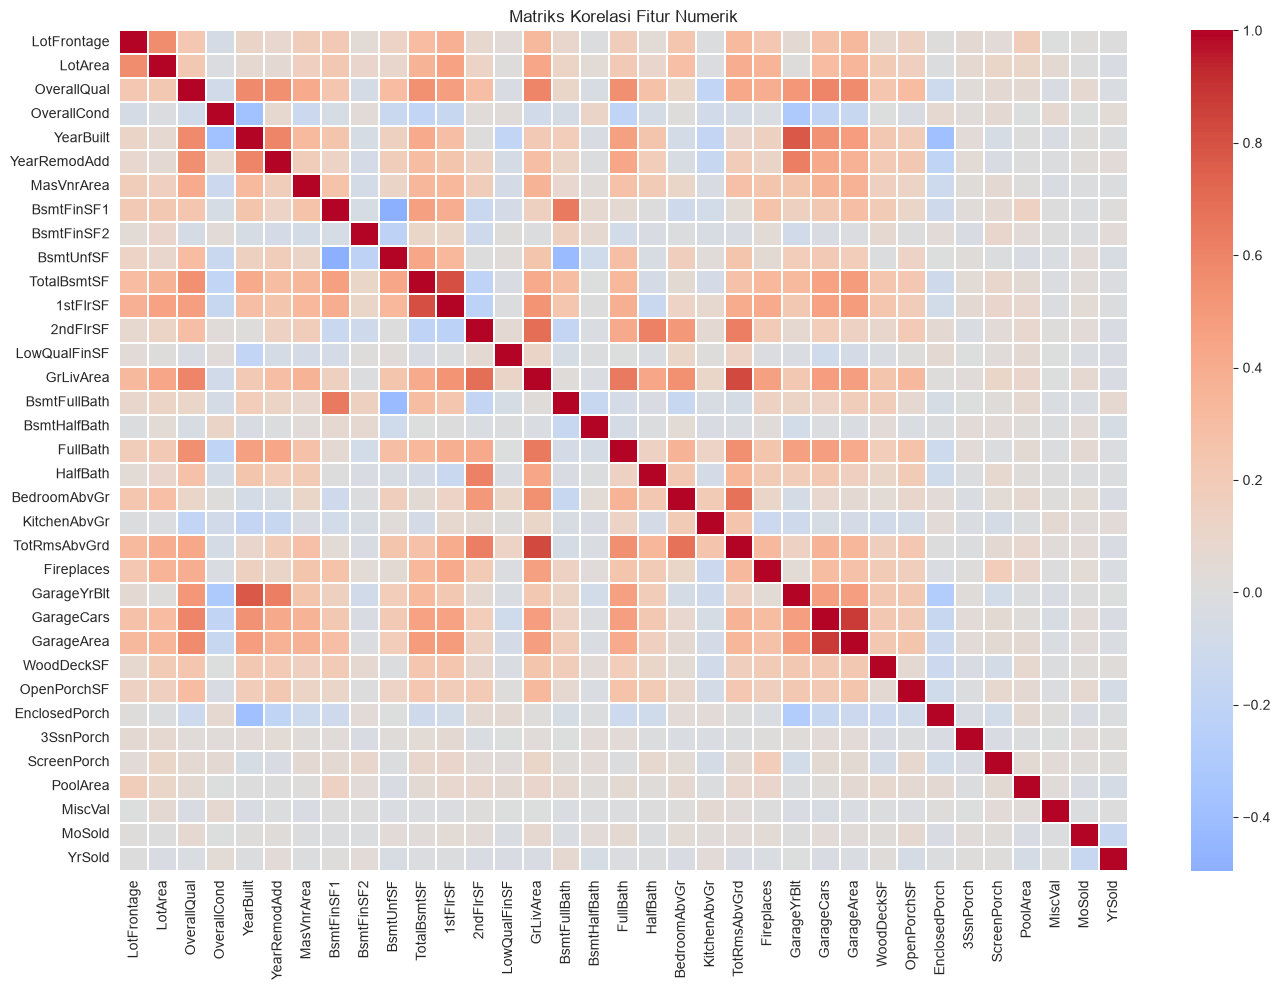

In [84]:
# Hanya fitur numerik yang relevan untuk correlation-based reduction.
correlation_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in ['Id', 'SalePrice']
]

corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.3
)
plt.title('Matriks Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

In [85]:
# Cari pasangan fitur dengan korelasi tinggi (>0.8).
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]

        if abs(val) > 0.8:
            high_corr_pairs.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    round(float(val), 3)
                )
            )

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=['Atribut 1', 'Atribut 2', 'Korelasi']
)

display(high_corr_df)

,Atribut 1,Atribut 2,Korelasi
0,TotalBsmtSF,1stFlrSF,0.807
1,GrLivArea,TotRmsAbvGrd,0.836
2,GarageCars,GarageArea,0.882


**Hasil:** Pasangan fitur dengan korelasi absolut di atas 0.8 dianggap sangat berkorelasi. Untuk setiap pasangan, salah satu atribut dibuang untuk mengurangi redundansi. Aturan pemilihan dibuat sederhana dan konsisten: atribut kedua pada setiap pasangan yang ditemukan oleh matriks korelasi akan dibuang.

In [86]:
# Buang satu atribut dari setiap pasangan korelasi tinggi.
# Aturan: atribut kedua (pair[1]) pada setiap pasangan dibuang.
cols_to_drop_corr = [
    pair[1]
    for pair in high_corr_pairs
    if pair[1] in df_encoded.columns
]

cols_to_drop_corr = list(dict.fromkeys(cols_to_drop_corr))

print("Kolom yang dibuang karena korelasi tinggi:")
print(cols_to_drop_corr)

df_encoded = df_encoded.drop(
    columns=cols_to_drop_corr
)

print(
    "Shape setelah reduksi atribut berkorelasi tinggi:",
    df_encoded.shape
)

Kolom yang dibuang karena korelasi tinggi:
['1stFlrSF', 'TotRmsAbvGrd', 'GarageArea']
Shape setelah reduksi atribut berkorelasi tinggi: (1460, 255)


### 5.2 PCA (Principal Component Analysis)

PCA digunakan untuk benar-benar mengurangi dimensi data dan menunjukkan jumlah komponen yang diperlukan untuk mempertahankan minimal 90% variansi.

Input PCA berasal dari dataset hasil preprocessing setelah correlation-based feature reduction. `Id` dan `SalePrice` tidak dimasukkan ke PCA.

In [87]:
pca_feature_cols = [
    c for c in df_encoded.columns
    if c not in ['Id', 'SalePrice']
]

pca_features = df_encoded[pca_feature_cols]

print("Shape input PCA:", pca_features.shape)

Shape input PCA: (1460, 253)


In [88]:
# PCA awal digunakan untuk menghitung cumulative explained variance.
pca_full = PCA()
pca_full.fit(pca_features)

explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

n_components_90 = (
    np.argmax(cum_explained_var >= 0.90) + 1
)

print(
    "Jumlah komponen yang diperlukan untuk menjelaskan >=90% variansi:",
    n_components_90
)
print(
    "Jumlah fitur sebelum PCA:",
    pca_features.shape[1]
)

Jumlah komponen yang diperlukan untuk menjelaskan >=90% variansi: 47
Jumlah fitur sebelum PCA: 253


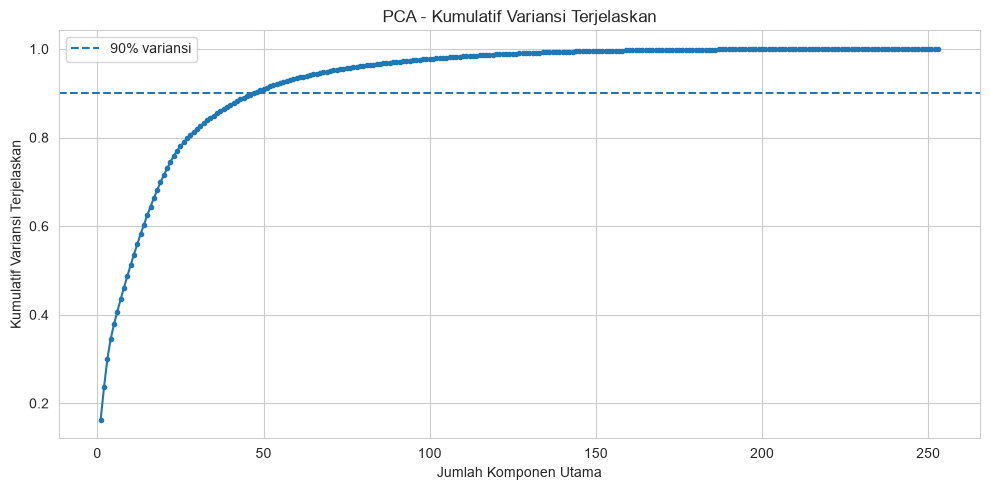

In [89]:
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(cum_explained_var) + 1),
    cum_explained_var,
    marker='o',
    markersize=3
)
plt.axhline(
    0.90,
    linestyle='--',
    label='90% variansi'
)
plt.xlabel('Jumlah Komponen Utama')
plt.ylabel('Kumulatif Variansi Terjelaskan')
plt.title('PCA - Kumulatif Variansi Terjelaskan')
plt.legend()
plt.tight_layout()
plt.show()

In [90]:
# Lakukan transformasi PCA secara nyata.
pca_final = PCA(n_components=n_components_90)
X_pca = pca_final.fit_transform(pca_features)

pca_df = pd.DataFrame(
    X_pca,
    columns=[
        f'PC{i}'
        for i in range(1, n_components_90 + 1)
    ]
)

print("Shape sebelum PCA:", pca_features.shape)
print("Shape setelah PCA:", pca_df.shape)
print("Jumlah komponen PCA:", pca_df.shape[1])

display(pca_df.head())

Shape sebelum PCA: (1460, 253)
Shape setelah PCA: (1460, 47)
Jumlah komponen PCA: 47


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47
0,2.380136,-0.135589,-1.501578,-2.573079,1.135135,0.340320,0.538404,0.790191,0.145932,-0.840074,0.553313,-0.408745,-0.027018,0.531544,-0.860027,-0.973076,-0.286993,-0.381640,-0.508852,0.605245,-0.165806,-0.076640,-0.001340,-0.475651,0.133048,-0.017572,-0.830952,-0.580224,-0.080417,-0.265338,0.036587,0.342367,-0.174068,0.177267,0.079103,0.223695,0.437047,0.157544,0.003754,0.040605,-0.112789,0.237694,0.102573,-0.018762,0.020086,-0.035329,-0.022823
1,-0.149514,-1.018688,1.664977,0.110392,-1.612115,-1.345233,1.549479,-1.549874,-2.000734,0.676027,-1.341612,-1.515678,-1.821275,0.122390,-0.026047,0.005079,-1.158339,1.128267,-0.799395,0.172880,-0.105793,-0.519549,-0.223737,0.822953,1.318944,-0.524408,-0.038208,0.796659,-0.398059,-0.627227,0.697438,-0.509290,-0.556497,0.368664,0.524415,-0.362597,-0.719025,-0.744498,0.454882,0.265790,-0.103885,0.178139,0.045579,0.445482,1.340828,-0.119086,-0.413058
2,3.015128,0.387844,-0.762564,-1.786344,0.365916,-0.091708,-0.210260,-0.292033,0.135025,-0.368877,0.235991,0.758226,0.715521,0.022901,0.025880,-0.053937,-1.044606,-0.071714,0.664470,0.221523,-0.733896,0.101055,0.332700,-0.212454,-0.661757,-0.007396,-1.296433,-0.065631,0.140197,-0.118047,0.043664,0.176206,-0.184593,0.130449,0.142948,0.055058,-0.110840,0.265522,0.210797,-0.161296,-0.226705,-0.136655,0.057679,-0.085519,-0.082328,-0.334338,-0.426975
3,-0.845511,1.573413,0.622005,-0.021095,-0.170584,2.702671,-0.959953,0.532640,0.088588,-1.069019,-1.893933,1.437579,-0.033605,2.016806,-0.401000,-1.373484,-1.242186,-0.291444,-1.288850,0.022620,1.135083,-0.558387,-0.129236,0.657492,-0.810148,1.271541,0.682006,0.754263,1.129102,0.216440,0.143458,-0.333283,-0.156110,0.980460,-1.292365,0.473726,0.700690,-0.209165,-0.247950,-0.494848,0.769109,-0.169582,0.613243,0.036580,-0.616361,0.864759,0.041183
4,4.832027,1.271687,0.570327,-1.323412,0.583016,-0.270310,-0.263178,-0.864425,-0.411995,0.002588,-0.330464,0.708770,0.872573,-0.826353,-0.007191,-0.136842,-0.236458,-0.497147,1.356086,0.023645,0.235036,-0.006421,-0.258415,-0.050799,-0.709248,0.408072,-1.317287,0.058865,0.356332,-0.072006,-0.145374,-0.249854,-0.053651,0.080953,-0.167273,0.226559,-0.269416,-0.308539,0.477084,0.139928,0.187252,0.060915,0.188240,0.253545,0.321317,-0.067500,-0.360171


**Hasil:** PCA menghasilkan dataset baru dengan jumlah dimensi yang lebih sedikit, sementara cumulative explained variance menunjukkan proporsi variansi yang dipertahankan. Hasil PCA ini digunakan sebagai demonstrasi reduksi dimensi di notebook namun tidak digunakan sebagai CSV final.

## 6. Ringkasan Dataset Akhir dan Ekspor CSV

Dataset final adalah hasil preprocessing tanpa PCA: cleaning/missing value handling, penanganan outlier, standardisasi, one-hot encoding, dan correlation-based feature reduction. `Id` dipertahankan sebagai identifier, sedangkan `SalePrice` tetap dalam bentuk aslinya.

In [91]:
print("=== Ringkasan Dataset Akhir ===")
print("Jumlah baris :", df_encoded.shape[0])
print("Jumlah kolom :", df_encoded.shape[1])
print("Total nilai hilang :", int(df_encoded.isnull().sum().sum()))

print("Apakah Id masih ada? :", 'Id' in df_encoded.columns)
print("Apakah SalePrice masih ada? :", 'SalePrice' in df_encoded.columns)
print("Apakah ada kolom PCA? :", any(c.startswith('PC') for c in df_encoded.columns))

display(df_encoded.head())

=== Ringkasan Dataset Akhir ===
Jumlah baris : 1460
Jumlah kolom : 255
Total nilai hilang : 0
Apakah Id masih ada? : True
Apakah SalePrice masih ada? : True
Apakah ada kolom PCA? : False


,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,Fireplaces,GarageYrBlt,GarageCars,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSZoning_FV,MSZoning_RH,...,Electrical_Mix,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_None,FireplaceQu_Po,FireplaceQu_TA,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_None,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_None,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,-0.220875,-0.333244,0.651479,-0.517200,1.050994,0.878668,0.514104,0.575425,-0.288653,-0.944591,-0.488321,1.161852,-0.120242,0.428636,1.107810,-0.241061,0.789741,1.227585,0.163779,-0.211454,-0.951226,1.017598,0.311725,-0.752176,0.216503,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-1.599111,0.138777,208500,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
1,2,0.460320,-0.013189,-0.071836,2.179628,0.156734,-0.429577,-0.570750,1.171992,-0.288653,-0.641228,0.532289,-0.795163,-0.120242,-0.502349,-0.819964,3.948809,0.789741,-0.761621,0.163779,-0.211454,0.600495,-0.107927,0.311725,1.626195,-0.704483,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-0.489110,-0.614439,181500,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
2,3,-0.084636,0.446022,0.651479,-0.517200,0.984752,0.830215,0.325915,0.092907,-0.288653,-0.301643,-0.327437,1.189351,-0.120242,0.586571,1.107810,-0.241061,0.789741,1.227585,0.163779,-0.211454,0.600495,0.934226,0.311725,-0.752176,-0.070361,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,0.990891,0.138777,223500,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
3,4,-0.447940,-0.027104,0.651479,-0.517200,-1.863632,-0.720298,-0.570750,-0.499274,-0.288653,-0.061670,-0.739702,0.937276,-0.120242,0.443182,1.107810,-0.241061,-1.026041,-0.761621,0.163779,-0.211454,0.600495,0.809167,1.650307,-0.752176,-0.176048,4.092524,-0.116339,-0.270208,-0.068692,-0.087688,-1.599111,-1.367655,140000,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
4,5,0.641972,1.283733,1.374795,-0.517200,0.951632,0.733308,1.366489,0.463568,-0.288653,-0.174865,0.238172,1.617877,-0.120242,1.442744,1.107810,-0.241061,0.789741,1.227585,1.390023,-0.211454,0.600495,0.892540,1.650307,0.780197,0.563760,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,2.100892,0.138777,250000,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0


In [92]:
# Verifikasi akhir sebelum ekspor.
assert df_encoded.shape[0] == original_rows, "Jumlah baris berubah secara tidak diharapkan."
assert df_encoded.isnull().sum().sum() == 0, "Masih terdapat missing value."
assert 'Id' in df_encoded.columns, "Kolom Id tidak ditemukan."
assert 'SalePrice' in df_encoded.columns, "Kolom SalePrice tidak ditemukan."
assert not any(c.startswith('PC') for c in df_encoded.columns), "Kolom PCA masuk ke CSV final."

# Tidak boleh ada dummy column bertipe boolean.
bool_cols = df_encoded.select_dtypes(include=['bool']).columns.tolist()
assert not bool_cols, f"Masih terdapat kolom boolean: {bool_cols}"

print("Semua verifikasi akhir berhasil.")

Semua verifikasi akhir berhasil.


In [93]:
output_csv = '5054251037_Lioneil Diyoel Trystan Tikupadang_Tugas_Praproses_Data.csv'

df_encoded.to_csv(
    output_csv,
    index=False
)

print(f"Dataset hasil preprocessing berhasil disimpan sebagai '{output_csv}'.")

# Verifikasi file CSV hasil ekspor.
csv_check = pd.read_csv(output_csv)

print("Shape CSV:", csv_check.shape)
print("Total missing value CSV:", int(csv_check.isnull().sum().sum()))
print("Jumlah baris CSV:", csv_check.shape[0])
print("Jumlah kolom CSV:", csv_check.shape[1])

Dataset hasil preprocessing berhasil disimpan sebagai '5054251037_Lioneil Diyoel Trystan Tikupadang_Tugas_Praproses_Data.csv'.
Shape CSV: (1460, 255)
Total missing value CSV: 0
Jumlah baris CSV: 1460
Jumlah kolom CSV: 255


### Kesimpulan Ringkas

- Dataset telah dibersihkan dari atribut dengan missing value lebih dari 50% dan missing value yang tersisa telah ditangani.
- Outlier diperiksa dengan boxplot dan ringkasan IQR, beberapa atribut numerik yang dipilih ditangani dengan IQR capping tanpa menghapus baris.
- `MSSubClass` diperlakukan sebagai kategorikal, sedangkan atribut numerik yang relevan distandarisasi menggunakan StandardScaler.
- Atribut kategorikal diubah menjadi kolom biner 0/1 melalui one-hot encoding.
- Fitur numerik yang sangat berkorelasi dianalisis dan salah satunya pada setiap pasangan dipertahankan/dibuang berdasarkan aturan yang dijelaskan dalam notebook.
- PCA benar-benar dilakukan untuk menunjukkan reduksi dimensi, tetapi hasil PCA tidak digunakan untuk membentuk CSV final.
- CSV final berisi dataset hasil preprocessing sebelum PCA.